# Data-Driven Insights into Movie Box Office Success 
___
**Team**: Group 5  
**Contributors**: Reeves Gonah, Cynthia Jemutai, Eliud Kibet, Stephen Jilani, Mohamed Adan  
**Project**: Phase 2  
**Date**:  23-03-2026  
**Data Sources**: [Box Office Mojo](https://www.boxofficemojo.com/), [The Numbers](https://www.the-numbers.com/), [Internet Movie Datase - IMDB](https://www.imdb.com/), [The Movie Database - TMDB](https://www.themoviedb.org/) and [Rotten Tomatoes](https://www.rottentomatoes.com/)
___

## Introduction


The film industry is a high-risk, high-reward space where production decisions can significantly impact financial outcomes. For a new movie studio entering the market, understanding what drives box office success is critical to making informed investment choices. Rather than relying on intuition or trends alone, data can be used to uncover patterns that consistently influence a film’s performance.

This project explores historical movie data to identify the key factors associated with box office success. By combining financial data with attributes such as genre, release timing, and audience reception, the analysis aims to highlight which types of films tend to perform well and why.

The objective is not to build complex predictive models, but to extract clear, interpretable insights that can guide decision-making. The findings from this analysis are used to provide practical recommendations for a new movie studio on what kinds of films to produce, when to release them, and which factors to prioritize in order to maximize revenue potential.

## 1. Business Understanding

**Business Context**
* A new movie studio wants to enter the film industry but faces uncertainty around what drives box office success. Using historical movie data can help guide smarter production and release decisions.

**Business Objectives**
* Identify which types of movies generate the most revenue and the factors influencing movie performance in order to decide on which movies to consider for the pilot project. This yielded the following business specific objectives:
    *   To identify genres that are the most popular
    *   To establish genre generating most revenue or profit
    *   To analyse the effect of budget range on return investment


**Business Questions**
* The following are the key questions this analysis attempts to answer as they would directly inform procurement decisions:
1.  Which movie categories are the most popular? (To identify the market)
2.  Which movie categories are the most profitable? (To identify the popular-profitability relationship)
3.  What movie budget range maximizes Return On Investment?

**Success Criteria** 
* The business questions above will be considered well answered if three data-backed business recommendations with evident visual support are provided.

## 2. Data Understanding

**Data Source and Description**  

The data for this project was scraped from multiple movie industry databases and provided to by means of a zipped folder titled ZippedData in [this github repository.](https://github.com/learn-co-curriculum/dsc-phase-2-project-v3) 
This included data from Box Office Mojo, The Numbers, IMDb, TMDB, and Rotten Tomatoes as indicated in the project header. Box Office Mojo and The Numbers provide financial data such as box office revenue, while IMDb and TMDB offer descriptive information including genres, release dates, and ratings. Rotten Tomatoes contributes critic and audience scores. Together, these datasets provide a combination of financial performance and movie characteristics, allowing for a more well-rounded analysis of factors associated with box office success.

**Initial Data Load**  

Preliminary analysis on existing data to identify the form and metrics of our data was necessary

In [1]:
#Import the necessary Libraries for the project
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# %matplotlib.inline

Loading each of the datasets to identify useful data columns

In [2]:
#Box office movies as bom
bom = pd.read_csv("bom.movie_gross.csv")
bom.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [3]:
# the movie database as tmdb
tmdb = pd.read_csv("tmdb.movies.csv")
tmdb.head()

##### Observations: 
# First column is unnamed
# Release date is in full, we could shorten to the year

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


In [4]:
#The Numbers as tn
tn = pd.read_csv("tn.movie_budgets.csv")
tn.head()

##### Observations: 
#Change 'movie' to title
#Change release date to year
#Potential merge for budget and gross

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [5]:
# Rotten Tomatoes as rt
rt = pd.read_csv("rt.movie_info.tsv", sep='\t')
rt.head()

##### Observations: 
# unlikely to be used

,id,synopsis,rating,genre,director,writer,theater_date,dvd_date,currency,box_office,runtime,studio
0,1,"This gritty, fast-paced, and innovative police...",R,Action and Adventure|Classics|Drama,William Friedkin,Ernest Tidyman,"Oct 9, 1971","Sep 25, 2001",NaN,NaN,104 minutes,NaN
1,3,"New York City, not-too-distant-future: Eric Pa...",R,Drama|Science Fiction and Fantasy,David Cronenberg,David Cronenberg|Don DeLillo,"Aug 17, 2012","Jan 1, 2013",$,"600,000",108 minutes,Entertainment One
2,5,Illeana Douglas delivers a superb performance ...,R,Drama|Musical and Performing Arts,Allison Anders,Allison Anders,"Sep 13, 1996","Apr 18, 2000",NaN,NaN,116 minutes,NaN
3,6,Michael Douglas runs afoul of a treacherous su...,R,Drama|Mystery and Suspense,Barry Levinson,Paul Attanasio|Michael Crichton,"Dec 9, 1994","Aug 27, 1997",NaN,NaN,128 minutes,NaN
4,7,NaN,NR,Drama|Romance,Rodney Bennett,Giles Cooper,NaN,NaN,NaN,NaN,200 minutes,NaN


In [6]:
#Rotten Tomato reviews as rt_reviews
# Use encoding to ignore dataset errors and subsequent runtime error
rt_reviews= pd.read_csv('rt.reviews.tsv', sep='\t',encoding='latin1')
rt_reviews.head()

,id,review,rating,fresh,critic,top_critic,publisher,date
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018"
1,3,It's an allegory in search of a meaning that n...,NaN,rotten,Annalee Newitz,0,io9.com,"May 23, 2018"
2,3,... life lived in a bubble in financial dealin...,NaN,fresh,Sean Axmaker,0,Stream on Demand,"January 4, 2018"
3,3,Continuing along a line introduced in last yea...,NaN,fresh,Daniel Kasman,0,MUBI,"November 16, 2017"
4,3,... a perverse twist on neorealism...,NaN,fresh,NaN,0,Cinema Scope,"October 12, 2017"


SQL was necessary to load the final dataset, im.db

In [7]:
#Create a connection to the database
conn = sqlite3.connect("im.db")

# Create a cursor to navigate the database
cur = conn.cursor()
cur.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")

In [8]:
#Retrieve the table names
table_names = cur.fetchall()
table_names

[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

In [9]:
# Joining the movie ratings table to the movie basics table via SQL joins
query = """
SELECT * 
FROM movie_basics as mb
JOIN movie_ratings as mr
ON mb.movie_id = mr.movie_id
ORDER BY start_year ASC;
"""
#Load the merged data into a new table, Internet Movie Database as imdb
imdb = pd.read_sql(query, conn)
imdb.head(10)


,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,movie_id,averagerating,numvotes
0,tt0146592,Pál Adrienn,Pál Adrienn,2010,136.0,Drama,tt0146592,6.8,451
1,tt0154039,So Much for Justice!,Oda az igazság,2010,100.0,History,tt0154039,4.6,64
2,tt0162942,Children of the Green Dragon,A zöld sárkány gyermekei,2010,89.0,Drama,tt0162942,6.9,120
3,tt0230212,The Final Journey,The Final Journey,2010,120.0,Drama,tt0230212,8.8,8
4,tt0312305,Quantum Quest: A Cassini Space Odyssey,Quantum Quest: A Cassini Space Odyssey,2010,45.0,"Adventure,Animation,Sci-Fi",tt0312305,5.1,287
5,tt0326592,The Overnight,The Overnight,2010,88.0,None,tt0326592,7.5,24
6,tt0326965,In My Sleep,In My Sleep,2010,104.0,"Drama,Mystery,Thriller",tt0326965,5.5,1889
7,tt0331312,This Wretched Life,This Wretched Life,2010,99.0,"Comedy,Drama",tt0331312,7.6,59
8,tt0337882,Blind Sided,Blind Sided,2010,NaN,"Comedy,Crime,Drama",tt0337882,7.4,14
9,tt0393049,Anderson's Cross,Anderson's Cross,2010,98.0,"Comedy,Drama,Romance",tt0393049,5.5,106


**Preliminary Observations and Conclusions**  

Based on earlier identified business objective and business questions, the following were the columns likely required:  
*   Genre 
*   Revenue: domestic gross + worldwide gross  
*   Budget   
*   Runtime  
*   Popularity: rating+ numvotes   
*   Title  
*   Year  
*   Studio

Datasets imdb and tn have all the information/columns necessary.
As such, imdb was selected as the primary dataset and tn(the numbers) as the secondary dataset 

## 3.Data Preparation and Cleaning

**Data Quality Assessment and Data Selection**  

The selected datasets were reloaded and examined to assess the integrity and quality of data

In [10]:
# Reloading the selected dataset: imdb
imdb

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,movie_id,averagerating,numvotes
0,tt0146592,Pál Adrienn,Pál Adrienn,2010,136.0,Drama,tt0146592,6.8,451
1,tt0154039,So Much for Justice!,Oda az igazság,2010,100.0,History,tt0154039,4.6,64
2,tt0162942,Children of the Green Dragon,A zöld sárkány gyermekei,2010,89.0,Drama,tt0162942,6.9,120
3,tt0230212,The Final Journey,The Final Journey,2010,120.0,Drama,tt0230212,8.8,8
4,tt0312305,Quantum Quest: A Cassini Space Odyssey,Quantum Quest: A Cassini Space Odyssey,2010,45.0,"Adventure,Animation,Sci-Fi",tt0312305,5.1,287
...,...,...,...,...,...,...,...,...,...
73851,tt9913056,Swarm Season,Swarm Season,2019,86.0,Documentary,tt9913056,6.2,5
73852,tt9913084,Diabolik sono io,Diabolik sono io,2019,75.0,Documentary,tt9913084,6.2,6
73853,tt9914286,Sokagin Çocuklari,Sokagin Çocuklari,2019,98.0,"Drama,Family",tt9914286,8.7,136
73854,tt9914942,La vida sense la Sara Amat,La vida sense la Sara Amat,2019,NaN,None,tt9914942,6.6,5


In [11]:
# missing values appear on runtime column, investigate

imdb['runtime_minutes'].isna().sum()

###Observation: 
# Many missing values from runtime column (roughly 10%)
# proceed for now

7620

The dataset was then loaded under the name primary_table, with only columns deemed necessary for analysis

In [12]:
# Listing necessary columns
columns = ['original_title', 'start_year','runtime_minutes','genres','averagerating','numvotes']
#Assigning new dataframe
primary_table = imdb[columns]
#primary_table

And the column titles were renamed

In [13]:
#Renaming the column titles
new_titles = ['Movie_Title','Year','Runtime','Genres','Average_Rating','Number_of_Votes']
primary_table.columns = new_titles

The same was done for the tn(the numbers) dataset

In [14]:
# Reloading the selected dataset: tn
tn

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


In [15]:
#Creating our secondary dataframe using only the columns we require from the tn database
columns_1 = ['movie','production_budget', 'domestic_gross','worldwide_gross']

secondary_table = tn[columns_1]
#secondary_table

In [16]:
#Renaming the column titles
new_titles_1 = ['Movie_Title','Production_Budget','Domestic_Revenue','Worldwide_Revenue']
secondary_table.columns = new_titles_1
secondary_table.head()

,Movie_Title,Production_Budget,Domestic_Revenue,Worldwide_Revenue
0,Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


**Data Merging**  

Before cleaning all rows and columns, merging was necessary so as only to be left with rows of movies appearing on both datasets. The movie title was selected as the merging key and as such needed to be cleaned on both tables prior to merging

In [17]:
#Create a function to remove whitespace from movie titles
def remove_whitespace(column):
    column = column.str.strip()
    return column

In [18]:
# Cleaning titles from the primary table

primary_table = primary_table.copy() # to avoid warning

#Remove whitespace from title column
primary_table['Movie_Title'] = remove_whitespace(primary_table['Movie_Title'])

In [19]:
# Cleaning titles from the primary table
secondary_table = secondary_table.copy()

#Remove whitespace from title column
secondary_table['Movie_Title'] = remove_whitespace(secondary_table['Movie_Title'])

With clean movie titles, merging was done

In [20]:
# Using the Movie Title column, lets merge the two tables into one movie database
movie_database = pd.merge(primary_table,secondary_table)
movie_database

,Movie_Title,Year,Runtime,Genres,Average_Rating,Number_of_Votes,Production_Budget,Domestic_Revenue,Worldwide_Revenue
0,The Overnight,2010,88.0,None,7.5,24,"$200,000","$1,109,808","$1,165,996"
1,The Overnight,2015,79.0,"Comedy,Mystery",6.1,14828,"$200,000","$1,109,808","$1,165,996"
2,Anderson's Cross,2010,98.0,"Comedy,Drama,Romance",5.5,106,"$300,000",$0,$0
3,Tangled,2010,100.0,"Adventure,Animation,Comedy",7.8,366366,"$260,000,000","$200,821,936","$586,477,240"
4,Dinner for Schmucks,2010,114.0,Comedy,5.9,91546,"$69,000,000","$73,026,337","$86,796,502"
...,...,...,...,...,...,...,...,...,...
2633,Happy Death Day 2U,2019,100.0,"Drama,Horror,Mystery",6.3,27462,"$9,000,000","$28,051,045","$64,179,495"
2634,Blinded by the Light,2019,117.0,"Biography,Comedy,Drama",6.2,173,"$15,000,000",$0,$0
2635,Heroes,2019,88.0,Documentary,7.3,7,"$400,000","$655,538","$655,538"
2636,Push,2019,92.0,Documentary,7.3,33,"$38,000,000","$31,811,527","$49,678,401"


This new table was renamed as movie database. Investigating the columns:

In [21]:
movie_database.isna().sum()

Movie_Title            0
Year                   0
Runtime              106
Genres                 5
Average_Rating         0
Number_of_Votes        0
Production_Budget      0
Domestic_Revenue       0
Worldwide_Revenue      0
dtype: int64

In [22]:
movie_database['Runtime'].describe()

count    2532.000000
mean      103.049368
std        20.360082
min         3.000000
25%        90.000000
50%       101.000000
75%       114.000000
max       189.000000
Name: Runtime, dtype: float64

In [23]:
#Filter those with missing genres
missing_genres = movie_database['Genres'].isna()
movie_database.loc[missing_genres]

,Movie_Title,Year,Runtime,Genres,Average_Rating,Number_of_Votes,Production_Budget,Domestic_Revenue,Worldwide_Revenue
0,The Overnight,2010,88.0,None,7.5,24,"$200,000","$1,109,808","$1,165,996"
55,Robin Hood,2018,NaN,None,7.6,5,"$210,000,000","$105,487,148","$322,459,006"
56,Robin Hood,2018,NaN,None,7.6,5,"$99,000,000","$30,824,628","$84,747,441"
85,The Bounty Hunter,2010,NaN,None,6.3,29,"$45,000,000","$67,061,228","$135,808,837"
2102,When the Bough Breaks,2017,93.0,None,6.1,8,"$10,000,000","$29,747,603","$30,768,449"


**Data Cleaning**  

A few issues were noted with the new dataset, such as column formatting and missing values

In [24]:
# Further Data Cleaning
# Checking the datatypes
movie_database.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2638 entries, 0 to 2637
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Movie_Title        2638 non-null   object 
 1   Year               2638 non-null   int64  
 2   Runtime            2532 non-null   float64
 3   Genres             2633 non-null   object 
 4   Average_Rating     2638 non-null   float64
 5   Number_of_Votes    2638 non-null   int64  
 6   Production_Budget  2638 non-null   object 
 7   Domestic_Revenue   2638 non-null   object 
 8   Worldwide_Revenue  2638 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 206.1+ KB


In [25]:
# Convert Revenue and Budget columns to integer

# Remove $ sign first
movie_database['Production_Budget'] = movie_database['Production_Budget'].str.replace(r'[$,]+','',regex=True)
movie_database['Domestic_Revenue'] = movie_database['Domestic_Revenue'].str.replace(r'[$,]+','',regex=True)
movie_database['Worldwide_Revenue'] = movie_database['Worldwide_Revenue'].str.replace(r'[$,]+','',regex=True)


# Convert to integer
movie_database['Production_Budget'] = movie_database['Production_Budget'].astype(int)
movie_database['Domestic_Revenue'] = movie_database['Domestic_Revenue'].astype(int)
movie_database['Worldwide_Revenue'] = pd.to_numeric(movie_database['Worldwide_Revenue'],errors='coerce')

# Confirm changes
movie_database.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2638 entries, 0 to 2637
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Movie_Title        2638 non-null   object 
 1   Year               2638 non-null   int64  
 2   Runtime            2532 non-null   float64
 3   Genres             2633 non-null   object 
 4   Average_Rating     2638 non-null   float64
 5   Number_of_Votes    2638 non-null   int64  
 6   Production_Budget  2638 non-null   int32  
 7   Domestic_Revenue   2638 non-null   int32  
 8   Worldwide_Revenue  2638 non-null   int64  
dtypes: float64(2), int32(2), int64(3), object(2)
memory usage: 185.5+ KB


**Additional Columns Creation**  

An additional 'Profit' column was deemed necessary. This was done by deducting the movie budget from its total revenue

In [34]:
#Creating a new calculated column for profit
movie_database['Profit'] = movie_database['Worldwide_Revenue'] - movie_database['Production_Budget']
movie_database.head()

,Movie_Title,Year,Runtime,Genres,Average_Rating,Number_of_Votes,Production_Budget,Domestic_Revenue,Worldwide_Revenue,Profit,ROI
0,The Overnight,2010,88.0,None,7.5,24,200000,1109808,1165996,965996,1037.902000
1,The Overnight,2015,79.0,"Comedy,Mystery",6.1,14828,200000,1109808,1165996,965996,1037.902000
2,Anderson's Cross,2010,98.0,"Comedy,Drama,Romance",5.5,106,300000,0,0,-300000,-100.000000
3,Tangled,2010,100.0,"Adventure,Animation,Comedy",7.8,366366,260000000,200821936,586477240,326477240,202.807375
4,Dinner for Schmucks,2010,114.0,Comedy,5.9,91546,69000000,73026337,86796502,17796502,131.627303


Simiilarly, a return on investment column was deemed as important, as it is more indicative on movie profitability as not all movies have similar production budgets

In [39]:
movie_database['ROI'] = (movie_database['Profit']/movie_database['Production_Budget'])
movie_database.head()

,Movie_Title,Year,Runtime,Genres,Average_Rating,Number_of_Votes,Production_Budget,Domestic_Revenue,Worldwide_Revenue,Profit,ROI
0,The Overnight,2010,88.0,None,7.5,24,200000,1109808,1165996,965996,4.829980
1,The Overnight,2015,79.0,"Comedy,Mystery",6.1,14828,200000,1109808,1165996,965996,4.829980
2,Anderson's Cross,2010,98.0,"Comedy,Drama,Romance",5.5,106,300000,0,0,-300000,-1.000000
3,Tangled,2010,100.0,"Adventure,Animation,Comedy",7.8,366366,260000000,200821936,586477240,326477240,1.255682
4,Dinner for Schmucks,2010,114.0,Comedy,5.9,91546,69000000,73026337,86796502,17796502,0.257920


**Final EDA Remarks**  

*       The runtime column now has only 106 null/missing values. These rows were not dropped as all other columns had their data present, and null values will not be used in computing descriptive statistics about movie runtime such as mean/count
*       There are some movie titles repeating. Since the year nor rating is the same, it was assumed that movies are different and as such those rows are not dropped
*       Five movies are missing genres. All other columns for these  rows contain data. They are not dropped as a result

## 4.Analysis

Based on the earlier identified business problems, Further analysis needs to be done to identify the relationships between data.

#### 1.) Business Objective I: To identify genres that are the most popular

*Establish the top movie genres according to voters, based on rating.*  

The purpose of this is to identify where the market is/ which movies appeal to the larger audience, by means of movie quality (rating), genre and popularity(number of voters, a high number indicates it was also widely watched)

* Movies are grouped by genre, treating a combination of genres as a genre itself.  

* Because not all movies/ movie genres have the same number of votes, the **weighted average** is computed to allow us to fairly determine the most popular genre of movies

* Movies with a vote count of less than 5 thousand are considered to not have enough votes to be considered fair to deduce judgement from

In [27]:
# Group the movies by genre
# Weighted Average Formula = sum(Average Rating * Number of Votes)/ sum(Total Votes for genre group)
grouped = (
    movie_database
    .groupby("Genres")
    .apply(lambda x: (x["Average_Rating"] * x["Number_of_Votes"]).sum() / x["Number_of_Votes"].sum())
    .to_frame(name="weighted_rating")
)

# Keep total voters for context
grouped["total_voters"] = movie_database.groupby("Genres")["Number_of_Votes"].sum()

# Keep the genre categories where the total voters are less than 5000
grouped = grouped[grouped["total_voters"] > 5000]


In [28]:
# Retrieve the top 10 values and store them in a database called top 10 (using descending order)
top_10 = grouped.sort_values(by="weighted_rating", ascending=False).head(10)

# Sort for horizontal plotting (for the visualization)
top_10 = top_10.sort_values(by="weighted_rating")


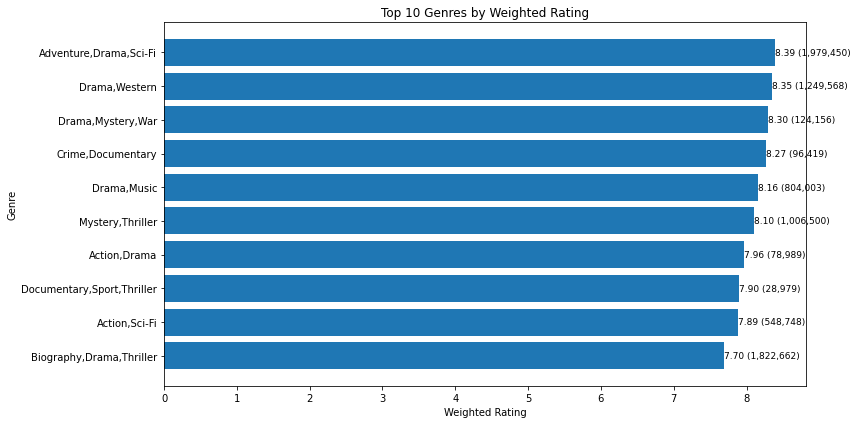

In [57]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# barh for horizontal bar graph
ax.barh(top_10.index, top_10["weighted_rating"])

# Set title and labels
ax.set_title("Top 10 Genres by Weighted Rating")
ax.set_xlabel("Weighted Rating")
ax.set_ylabel("Genre")

# Add labels (rating + voters) (found from online forum, adapted for this case)
for i, (rating, voters) in enumerate(zip(top_10["weighted_rating"], top_10["total_voters"])):
    ax.text(rating, i, f"{rating:.2f} ({voters:,})", va="center", fontsize=9)

plt.tight_layout()
plt.show()

From the Graph above, we can conclude that the most popular movies are of the drama genre in combination with high-engagement elements like sci-fi, adventure, or mystery. These have very high vote counts indicating a larger audience, and high ratings (above 8.0) which show a prime market for movie creation. The key observations from this analyis and its resulting visualization can be summarized as follows;

**Key Observations:**
*       Adventure, Drama, Sci-Fi lead in both rating and total voters. 
*       Genres like Drama, Western and Mystery, Thriller also achieve strong ratings at scale, indicating broad audience appeal.
*       In contrast, some high-rated genres with low voter counts suggest niche interest (e.g War, Sport, Documentary)



#### 2.) Business Objective II: To establish genre generating most revenue or profit

Establish the relationship between the movie genre and the total profit to identify those with the most upside for the new in-house movie studio.  
Focus is done on the top 10 movie genres identified earlier

In [43]:
# Creating a dataframe to group the movie by genres and compute the average roi
genre_profitability = (
    movie_database.groupby('Genres')['ROI']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
genre_profitability.head()

,Genres,ROI
0,"Crime,Drama,Family",62.119120
1,"Biography,Documentary",52.616649
2,"Drama,Family,Fantasy",47.260224
3,"Action,Comedy,Drama",32.876039
4,Crime,27.873195


In [44]:
# Recall the earlier created genre popularity table
grouped.head()

,weighted_rating,total_voters
Genres,,
Action,5.434337,60425
"Action,Adventure",5.800000,6955
"Action,Adventure,Animation",7.604005,3046710
"Action,Adventure,Biography",7.650532,945069
"Action,Adventure,Comedy",7.312251,6051788


In [ ]:
# Merging the popularity table and the average roi table for comparison purposes
#use join
genre_comparison = pd.merge(
    grouped,
    genre_profitability,
    on='Genres',
    how='inner'
)
genre_comparison.head()

,Genres,weighted_rating,total_voters,ROI
0,Action,5.434337,60425,2.175336
1,"Action,Adventure",5.800000,6955,-0.997384
2,"Action,Adventure,Animation",7.604005,3046710,2.454735
3,"Action,Adventure,Biography",7.650532,945069,1.475850
4,"Action,Adventure,Comedy",7.312251,6051788,3.310098


In [68]:
# Now sorting them in descending order
genre_comparison['popularity_rank'] = genre_comparison['weighted_rating'].rank(ascending=False, method='min')
genre_comparison['profitability_rank'] = genre_comparison['ROI'].rank(ascending=False, method='min')

genre_comparison = genre_comparison.sort_values('popularity_rank')
genre_comparison.head(10)

,Genres,weighted_rating,total_voters,ROI,popularity_rank,profitability_rank
80,"Adventure,Drama,Sci-Fi",8.393847,1979450,4.052996,1.0,35.0
200,"Drama,Western",8.345026,1249568,0.982682,2.0,133.0
187,"Drama,Mystery,War",8.300000,124156,1.358580,3.0,116.0
147,"Crime,Documentary",8.267729,96419,1.563472,4.0,104.0
180,"Drama,Music",8.155639,804003,1.550099,5.0,105.0
214,"Mystery,Thriller",8.098578,1006500,0.249034,6.0,170.0
37,"Action,Drama",7.961615,78989,1.201406,7.0,123.0
161,"Documentary,Sport,Thriller",7.900000,28979,-1.000000,8.0,217.0
56,"Action,Sci-Fi",7.889321,548748,0.303344,9.0,168.0
107,"Biography,Drama,Thriller",7.696396,1822662,2.189535,10.0,74.0


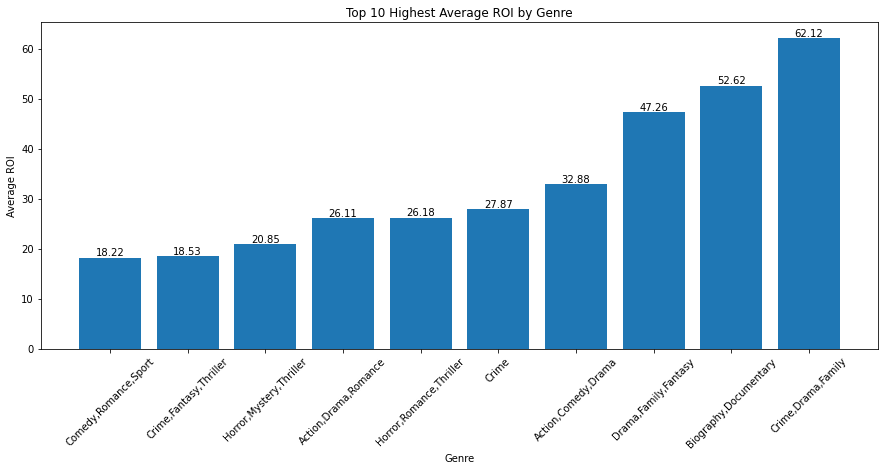

In [58]:
# Visualizing the results
#Start by visualizing the movie genres with the highest return on investment

# Create the plot figure
plt.figure(figsize=(15, 6))

#Get the movie genres with the highest ROI (Top 10)
top_10_ROI = genre_profitability.sort_values('ROI', ascending=False).head(10)

# Sort for horizontal plotting (for the visualization)
top_10_ROI = top_10_ROI.sort_values(by="ROI")

bars = plt.bar(top_10_ROI['Genres'], top_10_ROI['ROI'])
# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.ylabel('Average ROI')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.title('Top 10 Highest Average ROI by Genre')
plt.show()

**Key Observations**

*       The top ROI genres are spread across a mix of genres

*       Many of the highest-performing films are multi-genre combinations

*       Popularity does not necessarily translate into strong profit performance.



#### 3.) Business Objective II: To analyse the effect of budget range on return investment

Identify the budget range that provides the most upsside for the new movie studio, to prevent or minimize sunken costs.

In [70]:
# Create Budget bins to group movies by
bins = [0, 10e6, 50e6, 100e6, np.inf]
labels = ['Low (<10M)', 'Mid (10–50M)', 'High (50–100M)', 'Blockbuster (100M+)']

movie_database['budget_range'] = pd.cut(movie_database['Production_Budget'], bins=bins, labels=labels)

In [73]:
# Then Aggregate metrics (mean, median, count) by budget range
summary = movie_database.groupby('budget_range').agg({
    'ROI': ['mean', 'median'],
    'Profit': ['mean', 'median'],
    'Production_Budget': 'count'
}).reset_index()

summary.columns = ['budget_range', 'roi_mean', 'roi_median', 'profit_mean', 'profit_median', 'count']

summary.head()

,budget_range,roi_mean,roi_median,profit_mean,profit_median,count
0,Low (<10M),5.267657,-0.444355,1.296276e+07,-172398,1055
1,Mid (10–50M),1.722058,0.732457,4.193168e+07,17811261,1056
2,High (50–100M),1.685814,0.953429,1.228031e+08,71487563,293
3,Blockbuster (100M+),2.286905,1.969215,3.754361e+08,300391735,234


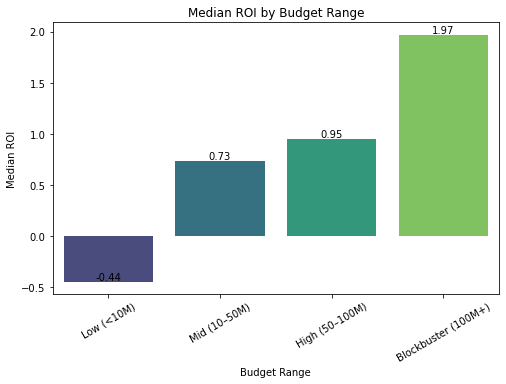

In [83]:
# Option 1: Bar plot
# Create plot figure
plt.figure(figsize=(8,5))

# select data into bar graph (median ROI is selected to eliminate bias due to outliers)
ax = sns.barplot(data=summary, x='budget_range', y='roi_median', palette='viridis')

# Add labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,  # x position
        height,                         # y position
        f'{height:.2f}',               # label (2 decimal places)
        ha='center',
        va='bottom'
    )

# Plot Labels
plt.title('Median ROI by Budget Range')
plt.ylabel('Median ROI')
plt.xlabel('Budget Range')
plt.xticks(rotation=30)
plt.show()

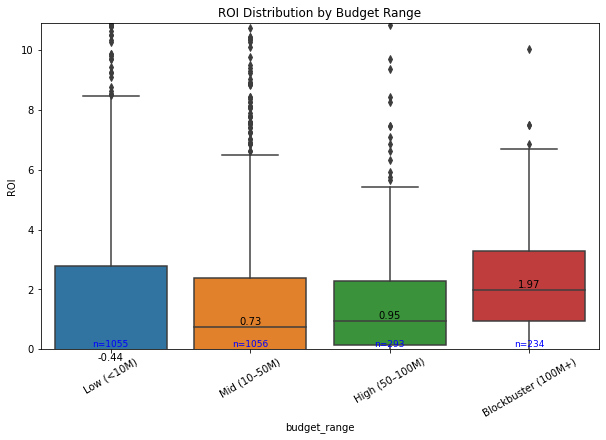

In [87]:
# Option 2: Box plots for distribution illustration
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=movie_database, x='budget_range', y='ROI')

# Add median labels
medians = movie_database.groupby('budget_range')['ROI'].median()

for i, median in enumerate(medians):
    ax.text(i, median, f'{median:.2f}', 
            ha='center', va='bottom', color='black', fontsize=10)
    
counts = movie_database['budget_range'].value_counts().sort_index()

for i, count in enumerate(counts):
    ax.text(i, 0, f'n={count}', 
            ha='center', va='bottom', fontsize=9, color='blue')

plt.title('ROI Distribution by Budget Range')
plt.ylim(0, movie_database['ROI'].quantile(0.95))
plt.xticks(rotation=30)

plt.show()

In [77]:
# Identify the best budget range
best_range = summary.loc[summary['roi_median'].idxmax(), 'budget_range']
print("Best budget range based on median ROI:", best_range)

Best budget range based on median ROI: Blockbuster (100M+)


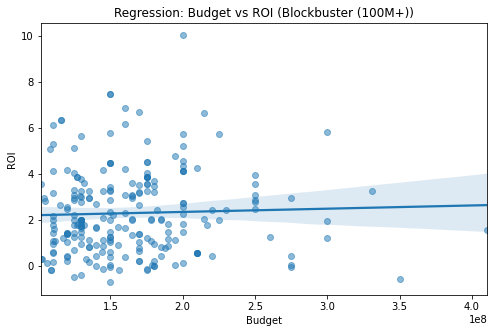

In [80]:
#Filter the data for that budget range
best_df = movie_database[movie_database['budget_range'] == best_range]

# Create a regression plot for the selected budget range
plt.figure(figsize=(8,5))
sns.regplot(data=best_df, x='Production_Budget', y='ROI', scatter_kws={'alpha':0.5})
plt.title(f'Regression: Budget vs ROI ({best_range})')
plt.xlabel('Budget')
plt.ylabel('ROI')
plt.show()

Assesment of the Return on investment was based on the following scale:  
*   Low budget: < 10M
*   Medium: 10M–50M
*   High: 50M–100M
*   Blockbuster: 100M+

**Key Observations**

*       ROI increases with budget, with blockbuster film range (100+ M) delivering the highest median returns.
*       Low-budget films (<10 M) consistently generate the lowest ROI, suggesting limited revenue scalability.
*       Blockbuster films (100+ M) are few, indicating high selectivity and potential barriers to entry.


## 5.Business Recommendations

Recommendations were done based on the specific objectives i.e the business questions identified earlier.

**1.Identifying genres that are the most popular**
*   Focus on drama-driven hybrid genres with mass appeal (such as a combination with adventure, sci-fi)is likely to yield the best returns, while niche genres (such as documentary, sports, thriller) are better suited for targeted audiences.

**2.To establish the genre that generates the most revenue/Profit**
*   The studio should not rely on popularity alone when choosing what films to produce. Instead, it should focus more on genres and genre combinations (especially drama with other genres such as action comedy and crime) which have strong ROI potential

**3.To analyse the effect of budget range on return on investment (ROI)**
*   Focus on selectively investing in high-budget (100+ M) films, prioritizing projects with strong success indicators (e.g., established franchises or proven talent), to maximize ROI while managing the risks associated with large-scale production.

## 6. Conclusion and Next Steps

Overall, the analysis shows that successful film production decisions require a balance between targetting audience appetite, revenue potential, and strategic investment. While popular genres attract wide audiences, the most profitable outcomes come from thoughtful genre combinations and well-targeted high-budget projects. In particular, blending drama genre with commercially strong genres (such as action and adventure) and selectively backing high-budget productions offers the best opportunity to maximize returns.

Given time and extra resources, the studio should deepen this analysis by exploring additional drivers of success, such as cast, directors, release timing, and franchise effects, to better inform high-budget investment decisions. Incorporating predictive modeling and continuously updating insights with new data will also help refine strategy and ensure more consistent, data-driven film production choices.